In [2]:
#!/usr/bin/env python3
import os
import sys
import argparse
import logging
import h5py
import numpy as np
import torch

# =====================================================================
# 1. CLUSTER CITIZENSHIP & RESOURCE TUNING
# =====================================================================
# Cap CPU threads BEFORE importing heavy libraries to prevent core saturation
MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)
torch.set_num_threads(MAX_CPU_THREADS)

def setup_environment():
    """Configures clean console logging streamed directly to standard output (handled by SBATCH)."""
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout)
        ]
    )
    return logging.getLogger("BrainLM_Cluster")

# =====================================================================
# 2. PIPELINE CORE FUNCTIONS
# =====================================================================
# def load_brainlm_model(hf_repo, subfolder):
#     """Initializes and freezes the BrainLM architecture."""
#     logging.info("Loading Model Configuration and Architecture from HuggingFace...")
#     from brainlm_mae.modeling_brainlm import BrainLMForPretraining
#     from brainlm_mae.configuration_brainlm import BrainLMConfig
    
#     config = BrainLMConfig.from_pretrained(hf_repo, subfolder=subfolder)
#     model = BrainLMForPretraining.from_pretrained(hf_repo, subfolder=subfolder, config=config)
    
#     model.eval()
#     model.config.mask_ratio = 0.0 
    
#     # Freeze all parameters explicitly to optimize back-end execution graph
#     for param in model.parameters():
#         param.requires_grad = False
        
#     return model

def load_brainlm_model(checkpoint_path):
    """Initializes and freezes the BrainLM architecture from a local checkpoint."""
    logging.info("Loading Model Configuration and Architecture from local checkpoint...")
    from brainlm_mae.modeling_brainlm import BrainLMForPretraining
    from brainlm_mae.configuration_brainlm import BrainLMConfig

    config = BrainLMConfig.from_pretrained(checkpoint_path)
    model  = BrainLMForPretraining.from_pretrained(checkpoint_path, config=config)

    model.eval()
    model.config.mask_ratio = 0.0

    for param in model.parameters():
        param.requires_grad = False

    return model

def load_spatial_coordinates(coords_file):
    """Loads MNI spatial coordinates and prepares tensor format."""
    logging.info(f"Loading spatial coordinates from: {coords_file}")
    if not os.path.exists(coords_file):
        raise FileNotFoundError(f"Coordinates file missing at: {coords_file}")
    
    real_coords = np.loadtxt(coords_file)[:, 1:4] 
    return torch.tensor(real_coords, dtype=torch.float32).unsqueeze(0)

def preprocess_subject_data(raw_ts, num_windows=3, window_size=490):
    """Applies Robust Scaling and sections data into sliding windows."""
    # Orient to [424, num_timepoints]
    dat_arr = raw_ts.T
    
    # Strip out trailing NaNs if present
    invalid_cols = np.isnan(dat_arr).any(axis=0)
    if np.any(invalid_cols):
        dat_arr = dat_arr[:, ~invalid_cols]
        
    num_timepoints = dat_arr.shape[1]
    if num_timepoints < window_size:
        raise ValueError(f"Recording has {num_timepoints} TRs, but requires at least {window_size}.")

    # Robust Scaler (Median & IQR)
    for idx in range(dat_arr.shape[0]):
        voxel_data = dat_arr[idx, :]
        median = np.median(voxel_data)
        q75, q25 = np.percentile(voxel_data, [75, 25])
        iqr = q75 - q25
        if iqr == 0:
            iqr = 1e-6
        dat_arr[idx, :] = (voxel_data - median) / iqr

    # Sliding Window Generation
    windows = []
    step_size = (num_timepoints - window_size) // (num_windows - 1)

    for i in range(num_windows):
        start_idx = i * step_size
        end_idx = start_idx + window_size
        
        if i == num_windows - 1:
            end_idx = num_timepoints
            start_idx = num_timepoints - window_size
            
        windows.append(dat_arr[:, start_idx:end_idx])
        
    return torch.tensor(np.stack(windows, axis=0), dtype=torch.float32)


In [3]:
# --- PATH CONFIGURATION FROM BASH ---
PROJ_DIR = "/home/mossf/projects/brainlm"
DATA_DIR = "/share/data1/mossf/data/brainlm"

INPUT_H5 = f"{DATA_DIR}/input/fmri_timeseries_subset_100.h5"
OUTPUT_DIR = f"{DATA_DIR}/outputs/attention_matrices"
COORDS = f"{DATA_DIR}/input/toolkit/atlases/A424_Coordinates.dat"
# HF_LOCAL_REPO = f"{DATA_DIR}/input/brainlm_hf_model"
# SUBFOLDER = "vitmae_111M"
CHECKPOINT_PATH = f"{DATA_DIR}/input/pretrained_models/2023-06-06-22_15_00-checkpoint-1400"
OUT_DIR = f"{PROJ_DIR}/logs"

# --- DEVICE SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing environment utilizing device: {device}")

Testing environment utilizing device: cpu


In [9]:
# Assuming 'load_brainlm_model' and 'load_spatial_coordinates' are already defined
print("Loading model...")
# model = load_brainlm_model(HF_LOCAL_REPO, SUBFOLDER).to(device)
model = load_brainlm_model(CHECKPOINT_PATH).to(device)
model.eval() # Set model to evaluation mode for testing
print(model.config.num_timepoints_per_voxel)
print("Loading spatial coordinates...")
spatial_coords_base = load_spatial_coordinates(COORDS)

print("Model and coordinates loaded successfully!")

Loading model...
200
Loading spatial coordinates...
Model and coordinates loaded successfully!


In [6]:
# Choose which subject index you want to test
subject_index = 0  

with h5py.File(INPUT_H5, 'r') as f_in:
    ts_dataset = f_in['parcel_ts']
    sub_id = f_in['subject_ids'][subject_index].decode('utf-8')
    
    # 1. Extract and Transpose -> Shape: (424, 1000)
    raw_data = ts_dataset[subject_index, 100:-100, :].T

# 2. Robust Z-Scoring (Median/IQR) per region row
# Compute along axis=1 (the time dimension)
medians = np.median(raw_data, axis=1, keepdims=True)

q75, q25 = np.percentile(raw_data, [75, 25], axis=1, keepdims=True)
iqr = q75 - q25

# Prevent division by zero just in case a region has completely flat data
iqr = np.where(iqr == 0, 1.0, iqr)

# 3. Apply the scaling
normalized_data = (raw_data - medians) / iqr

In [7]:
np.shape(raw_data)

(424, 1000)

In [7]:
t_data = preprocess_subject_data(raw_ts=raw_data.T)
t_data.shape

torch.Size([3, 424, 490])

In [53]:
print("Formatting Time Windows (Sliding Window Inference)...")
window_size = 49
dat_arr = normalized_data.copy()
num_timepoints = dat_arr.shape[1]

if num_timepoints < window_size:
    raise ValueError(f"Recording has {num_timepoints} TRs, but requires at least {window_size}.")

windows = []

# Calculate how many windows we need and the step size between them
# We want the last window to perfectly align with the end of the recording
num_windows = 3 # You can adjust this. 3 is good for 1200 TRs.
step_size = (num_timepoints - window_size) // (num_windows - 1)

for i in range(num_windows):
    start_idx = i * step_size
    end_idx = start_idx + window_size
    
    # Ensure the last window doesn't go out of bounds due to rounding
    if i == num_windows - 1:
        end_idx = num_timepoints
        start_idx = num_timepoints - window_size
        
    # Extract the window
    chunk = dat_arr[:, start_idx:end_idx]
    windows.append(chunk)
    print(f" -> Created Window {i+1}: TRs {start_idx} to {end_idx}")

# Stack all windows into a single PyTorch tensor
# Shape changes from [424, 490] to [num_windows, 424, 490]
windows_array = np.stack(windows, axis=0)

# Convert to PyTorch Tensor 
tensor_data = torch.tensor(windows_array, dtype=torch.float32)
    
print(f"Success! Final Tensor Shape (Batch = Windows): {tensor_data.shape}")

Formatting Time Windows (Sliding Window Inference)...
 -> Created Window 1: TRs 0 to 49
 -> Created Window 2: TRs 475 to 524
 -> Created Window 3: TRs 951 to 1000
Success! Final Tensor Shape (Batch = Windows): torch.Size([3, 424, 49])


In [9]:
tensor_data_raw = torch.tensor(raw_data, dtype=torch.float32)
tensor_data_raw = tensor_data_raw.unsqueeze(0)
print(f"Success! Final Tensor Shape (Batch = Windows): {tensor_data_raw.shape}")

Success! Final Tensor Shape (Batch = Windows): torch.Size([1, 424, 1200])


In [6]:
# 1. Load the data
real_fmri_data_time1 = tensor_data[0] # first window

# 2. Check and adjust the shape
# torch.corrcoef expects a 2D tensor of shape (variables, observations).
# For an FC matrix, this means your data MUST be shaped as (Regions, Timepoints).
print(f"Original data shape: {real_fmri_data_time1.shape}")


# 3. Compute the Pearson Correlation Matrix
# This will output a matrix of shape (Regions, Regions)
fc_matrix_r = torch.corrcoef(real_fmri_data_time1)

print(f"FC Matrix shape: {fc_matrix_r.shape}")

Original data shape: torch.Size([424, 490])
FC Matrix shape: torch.Size([424, 424])


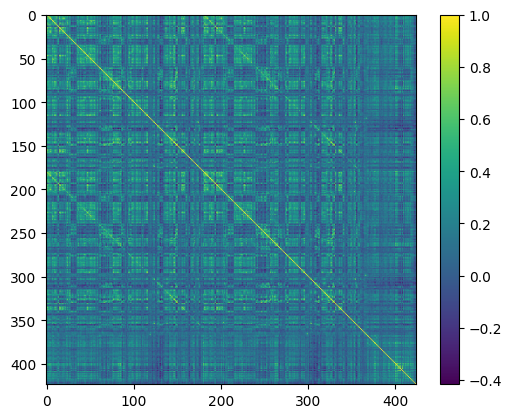

In [18]:
import matplotlib.pyplot as plt

plt.imshow(fc_matrix_r)
plt.colorbar()
plt.show()

Now to the model

- Coords shaping
- ts shaping

In [13]:
# Prepare the Model
# Ensure model is in evaluation mode and masking is turned off so we see the whole brain
model.eval()
model.config.mask_ratio = 0.0 


# THE FORWARD PASS: Extract Attention Matrices
with torch.no_grad():
    outputs = model.vit(
        signal_vectors=tensor_data,
        xyz_vectors=spatial_coords_base,
        output_attentions=True 
    )

attention_matrices = outputs.attentions
final_layer_attention = attention_matrices[-1]

In [ ]:
final_layer_attention.shape #batch, heads, regionsxtime_windows, regionsxtime_windows

torch.Size([3, 12, 4241, 4241])

mean-heads-and-time

Raw Attention Matrix Shape: torch.Size([3, 12, 4241, 4241])
Success! Final Region-to-Region Matrix shape: torch.Size([424, 424])


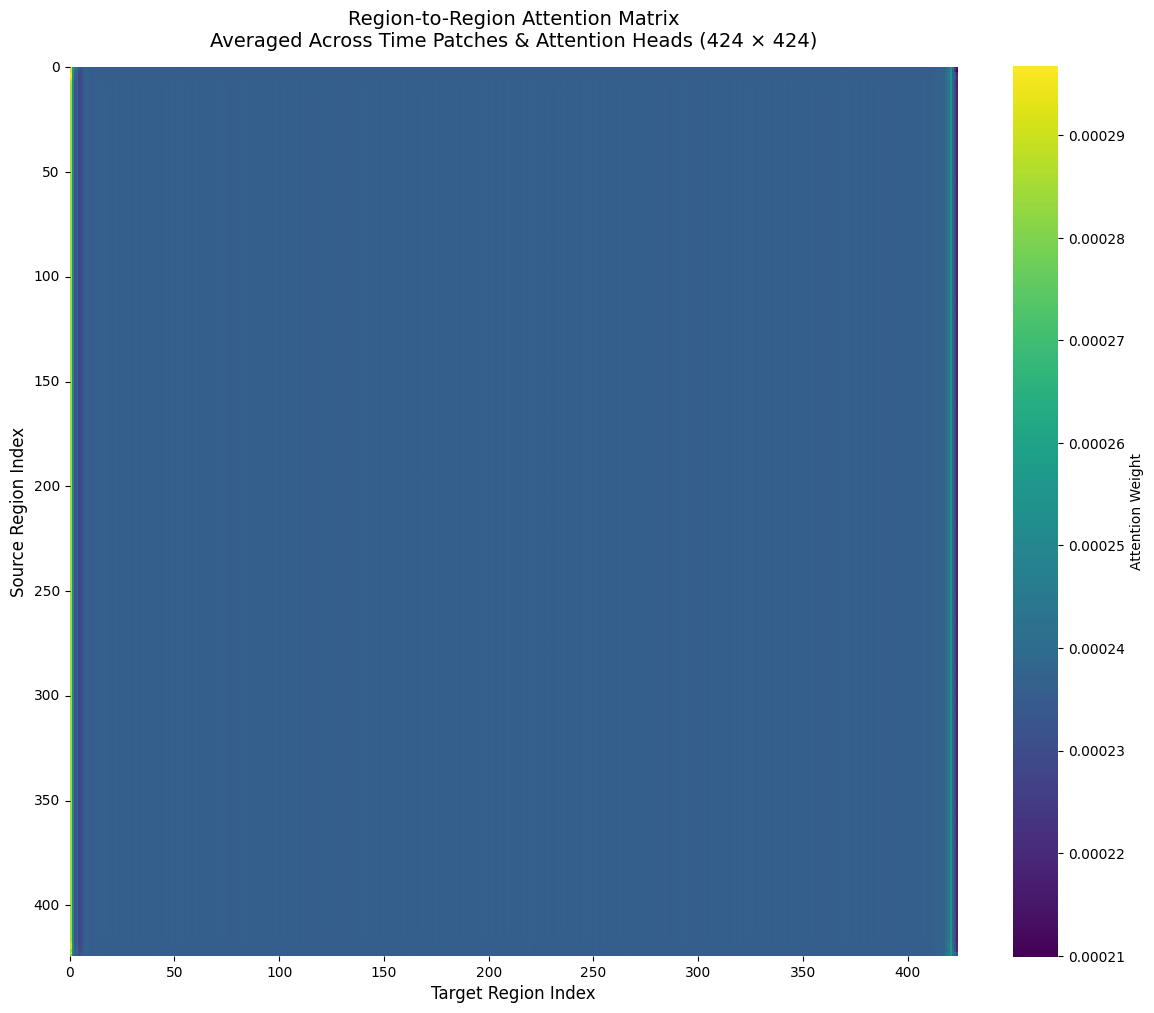

In [21]:
# Format check: [num_windows, num_heads, sequence_length, sequence_length]
print(f"Raw Attention Matrix Shape: {final_layer_attention.shape}")

# Process the Matrices into a single N.t x N.t --424.tx424.t-- Brain Network
# Average across the sliding Windows (dim 0) and the Attention Heads (dim 1)
# obs: for 1 time patch (of 3 time windows), mean(0) does nothing
# obs: the rela thing here to take the average of the attention heads to merge the data
avg_attention = final_layer_attention.mean(dim=(0, 1)) 

# Slice off the [CLS] token at index 0 (leaves 4240 x 4240 tokens
attn_no_cls = avg_attention[1:, 1:] 

# Reshape from [4240, 4240] back to [N regions, T patches, N regions, T patches]
# Reshape using our N regions and 3 patches
# attn_reshaped = attn_no_cls.view(num_regions, 3, num_regions, 3)

num_regions = 424
num_timepoints = 10

# Reshape from [4240, 4240] to [424, 10, 424, 10]
# Layout: [Source_Region, Source_Time, Target_Region, Target_Time]
attn_reshaped = attn_no_cls.view(num_regions, num_timepoints, num_regions, num_timepoints)

# Average across the "patch" dimensions to get final region-to-region attention
subject_attention_matrix = attn_reshaped.mean(dim=(1, 3))

print(f"Success! Final Region-to-Region Matrix shape: {subject_attention_matrix.shape}")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# 1. Convert the 424x424 PyTorch tensor to a numpy array safely
if isinstance(subject_attention_matrix, torch.Tensor):
    region_matrix = subject_attention_matrix.detach().cpu().numpy()
else:
    region_matrix = np.array(subject_attention_matrix)

# 2. Set up the figure (slightly larger to accommodate the 424x424 resolution)
plt.figure(figsize=(12, 10))

# 3. Plot the heatmap
# Note: rasterized=True keeps the notebook responsive and file sizes small when saving
ax = sns.heatmap(
    region_matrix, 
    cmap='viridis', 
    square=True, 
    cbar_kws={'label': 'Attention Weight'},
    rasterized=True 
)

# 4. Format the titles and labels
plt.title("Region-to-Region Attention Matrix\nAveraged Across Time Patches & Attention Heads (424 × 424)", fontsize=14, pad=15)
plt.xlabel("Target Region Index", fontsize=12)
plt.ylabel("Source Region Index", fontsize=12)

# 5. Handle ticks cleanly
# Individual labels for 424 items is too dense; showing intervals of 50 keeps it clean
tick_intervals = np.arange(0, 425, 50)
plt.xticks(tick_intervals, tick_intervals, rotation=0)
plt.yticks(tick_intervals, tick_intervals, rotation=0)

plt.tight_layout()
# plt.savefig("./figures/region_to_region_attention.png", dpi=300)
plt.show()

head-by-head

Total available attention heads: 12
Tensor shape per head: torch.Size([12, 424, 424])


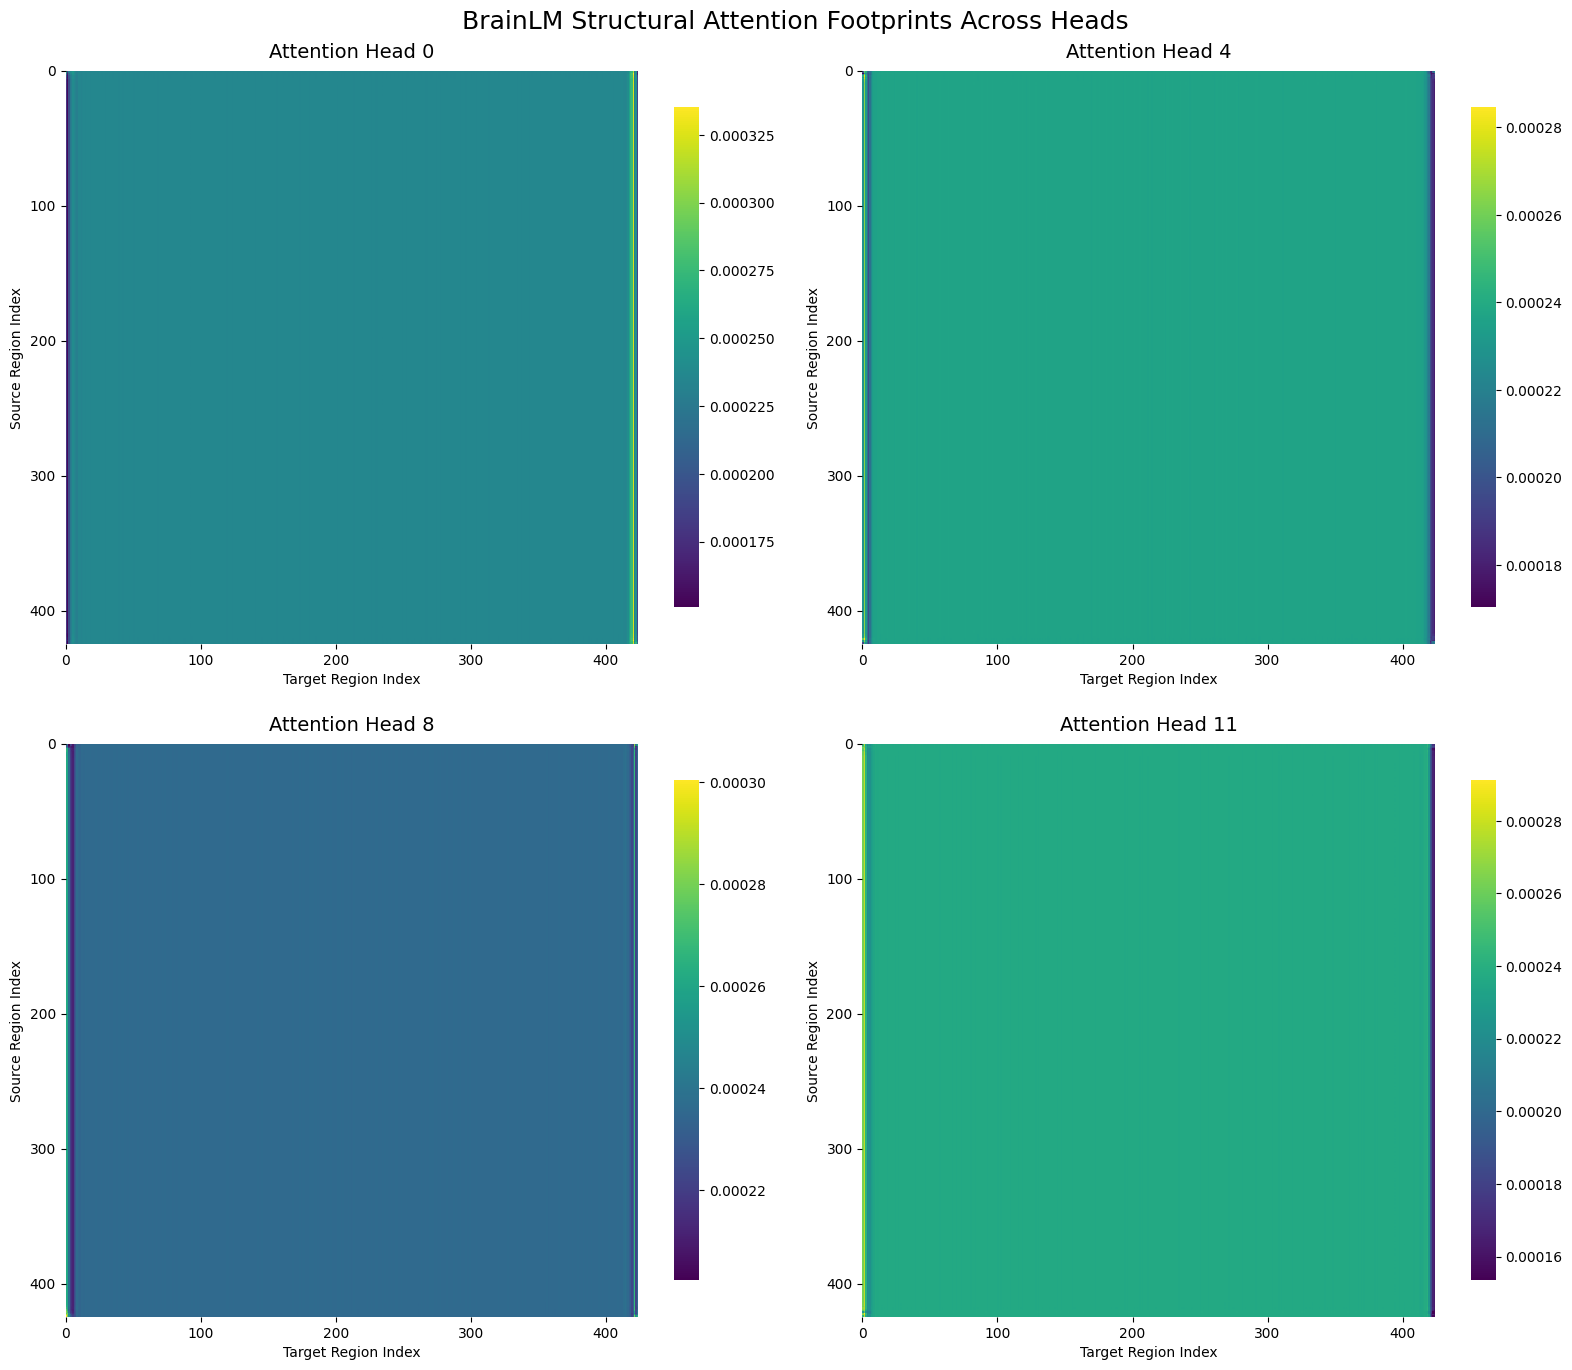

In [20]:
# 1. Average ONLY across sliding windows (dim 0), keeping heads (dim 1) intact
# Shape changes from [3, num_heads, 4241, 4241] to [num_heads, 4241, 4241]
avg_windows_attention = final_layer_attention.mean(dim=0)

# 2. Drop the [CLS] token at index 0 for both spatial dimensions
# Shape changes to: [num_heads, 4240, 4240]
heads_no_cls = avg_windows_attention[:, 1:, 1:]

num_heads = heads_no_cls.shape[0]
num_regions = 424
num_timepoints = 10

# 3. Reshape keeping the head dimension out front
# Layout: [Head, Source_Region, Source_Time, Target_Region, Target_Time]
heads_reshaped = heads_no_cls.view(num_heads, num_regions, num_timepoints, num_regions, num_timepoints)

# 4. Average across the timepoint patch dimensions (dim 2 and dim 4)
# Final Shape: [num_heads, 424, 424]
per_head_attention_matrices = heads_reshaped.mean(dim=(2, 4))

print(f"Total available attention heads: {num_heads}")
print(f"Tensor shape per head: {per_head_attention_matrices.shape}")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select any 4 heads you want to compare
heads_to_plot = [0, 4, 8, 11] 

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten() # Flatten 2D array of axes into a 1D list for easy looping

for idx, head_idx in enumerate(heads_to_plot):
    # Extract the matrix for the specific head and send to numpy
    matrix_to_plot = per_head_attention_matrices[head_idx].detach().cpu().numpy()
    
    # Plot heatmap on its designated grid axis
    sns.heatmap(
        matrix_to_plot, 
        cmap='viridis', 
        square=True, 
        cbar=True,
        rasterized=True, # Keeps notebook execution fast with 424x424 sizes
        ax=axes[idx],
        cbar_kws={'shrink': 0.8}
    )
    
    # Labeling individual subplots
    axes[idx].set_title(f"Attention Head {head_idx}", fontsize=14, pad=10)
    axes[idx].set_xlabel("Target Region Index", fontsize=10)
    axes[idx].set_ylabel("Source Region Index", fontsize=10)
    
    # Clear tick distribution (every 100 regions)
    tick_intervals = np.arange(0, 425, 100)
    axes[idx].set_xticks(tick_intervals)
    axes[idx].set_yticks(tick_intervals)
    axes[idx].set_xticklabels(tick_intervals, rotation=0)
    axes[idx].set_yticklabels(tick_intervals, rotation=0)

# Master layout configuration
plt.suptitle("BrainLM Structural Attention Footprints Across Heads", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

layer-by-layer

Total layers found in model: 12


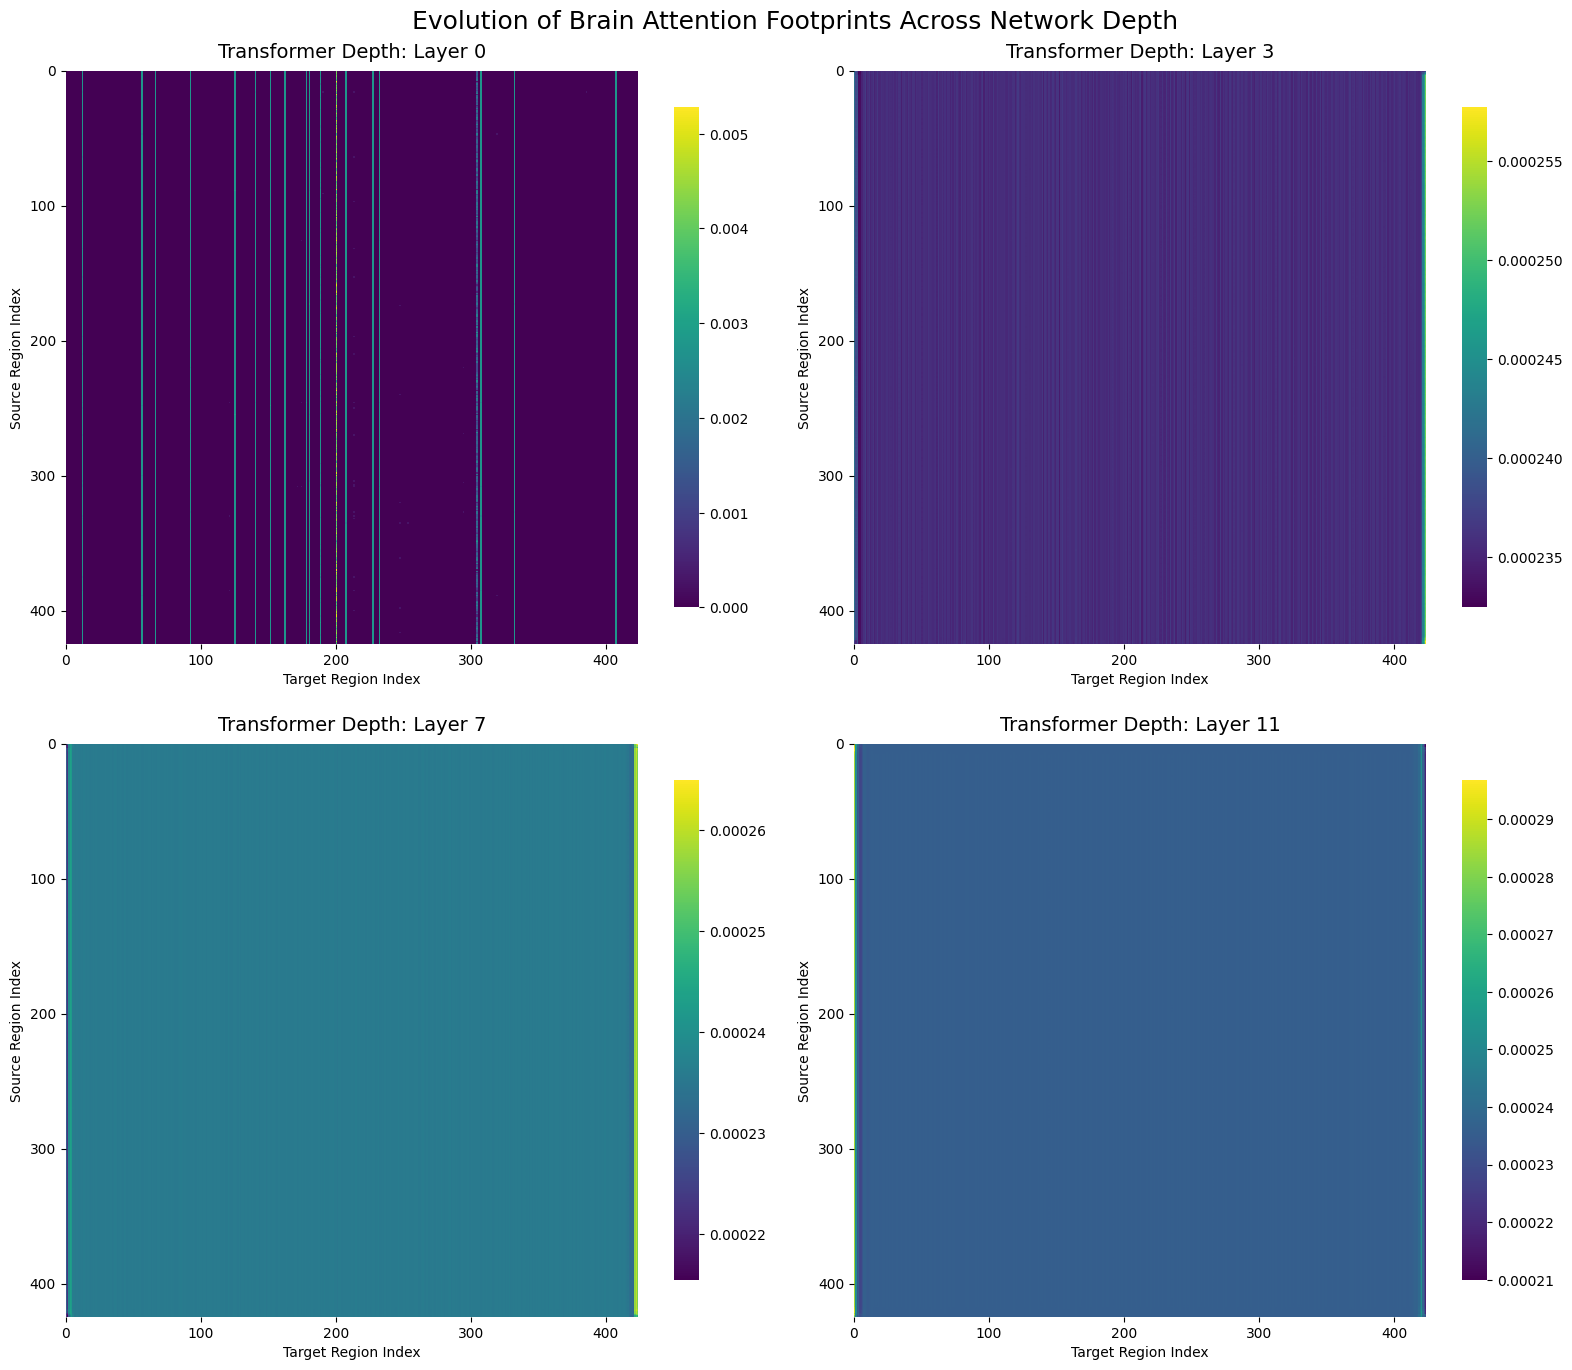

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 'attention_matrices' contains the outputs from all layers
total_layers = len(attention_matrices)
print(f"Total layers found in model: {total_layers}")

# Select which layers you want to inspect (e.g., early, middle, late, and final)
# For a 12-layer model, this picks Layer 0, Layer 3, Layer 7, and Layer 11
layers_to_plot = [0, 3, 7, total_layers - 1]

# Constants for reshaping
num_regions = 424
num_timepoints = 10

# Set up a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, layer_idx in enumerate(layers_to_plot):
    # 1. Grab the raw tensor for this specific layer
    # Shape: [num_windows, num_heads, 4241, 4241]
    layer_tensor = attention_matrices[layer_idx]
    
    # 2. Average across sliding windows (dim 0) and attention heads (dim 1)
    avg_attention = layer_tensor.mean(dim=(0, 1))  # Shape: [4241, 4241]
    
    # 3. Slice off the [CLS] token
    attn_no_cls = avg_attention[1:, 1:]  # Shape: [4240, 4240]
    
    # 4. Reshape to isolate time patches
    attn_reshaped = attn_no_cls.view(num_regions, num_timepoints, num_regions, num_timepoints)
    
    # 5. Average across time patches to get the final [424, 424] matrix
    layer_matrix = attn_reshaped.mean(dim=(1, 3)).detach().cpu().numpy()
    
    # 6. Plot the heatmap on its designated subplot axis
    sns.heatmap(
        layer_matrix, 
        cmap='viridis', 
        square=True, 
        cbar=True,
        rasterized=True, # Essential for keeping notebook memory usage low
        ax=axes[idx],
        cbar_kws={'shrink': 0.8}
    )
    
    # Labeling individual subplots
    axes[idx].set_title(f"Transformer Depth: Layer {layer_idx}", fontsize=14, pad=10)
    axes[idx].set_xlabel("Target Region Index", fontsize=10)
    axes[idx].set_ylabel("Source Region Index", fontsize=10)
    
    # Spread out the ticks cleanly
    tick_intervals = np.arange(0, 425, 100)
    axes[idx].set_xticks(tick_intervals)
    axes[idx].set_yticks(tick_intervals)
    axes[idx].set_xticklabels(tick_intervals, rotation=0)
    axes[idx].set_yticklabels(tick_intervals, rotation=0)

# Master Title Layout
plt.suptitle("Evolution of Brain Attention Footprints Across Network Depth", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

mini-model

In [24]:
print(spatial_coords_base.shape)
# spatial_coords is currently [1, 424, 3]. We need it to be [num_windows, 424, 3]
batched_coords = spatial_coords_base.repeat(num_windows, 1, 1)
print(batched_coords.shape)

# Grab just the first window
# We use 0:1 instead of just 0 so it keeps the batch dimension: [1, 424, 490]
single_window = tensor_data[0:1, :, :]

# Slice out 3 patches (49 TRs each) along the time dimension (dim=2)
# We will grab from the beginning, middle, and end of the 490 sequence
patch_1 = single_window[:, :, 0:49]          # First 49 TRs
patch_2 = single_window[:, :, 220:269]       # Middle 49 TRs
patch_3 = single_window[:, :, 441:490]       # Last 49 TRs

# Concatenate them along the time dimension
small_fmri_data = torch.cat([patch_1, patch_2, patch_3], dim=2)

print(small_fmri_data.shape)
print(tensor_data.shape)

torch.Size([1, 424, 3])
torch.Size([3, 424, 3])
torch.Size([1, 424, 147])
torch.Size([3, 424, 490])


Raw Attention Matrix Shape: torch.Size([3, 12, 501, 501])
Success! Final Region-to-Region Matrix shape: torch.Size([50, 50])


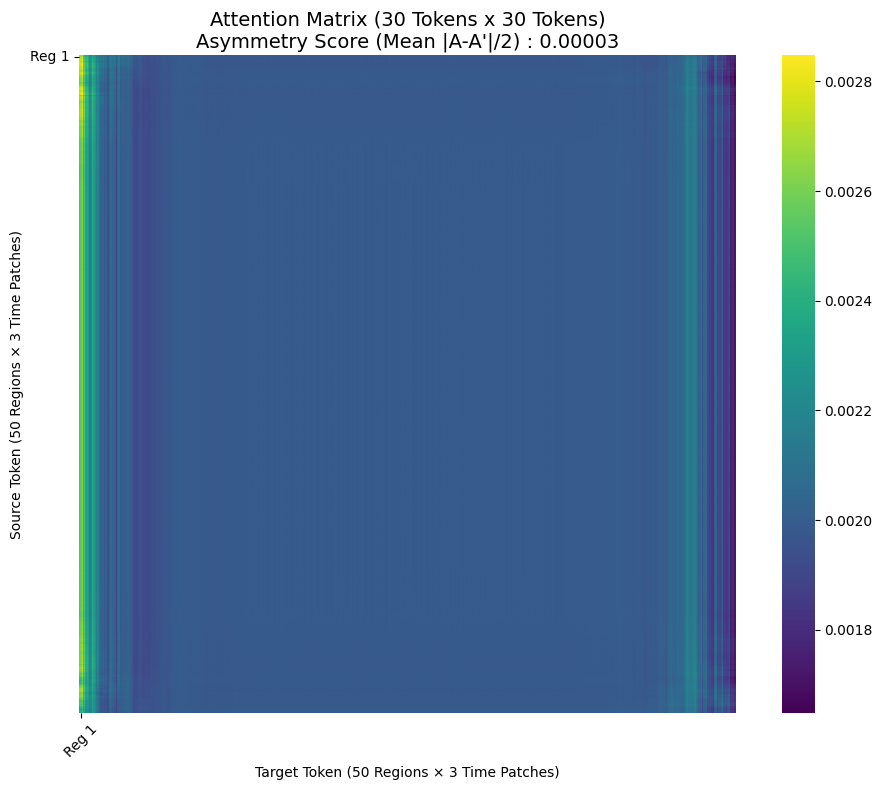

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Pick N specific regions (indices from 0 to 423)
# By spacing these out, we guarantee we are grabbing regions from 
# different hemispheres, lobes, and functional networks!

# selected_indices = [15, 60, 110, 160, 210, 260, 310, 360, 400, 420]
# selected_indices = np.linspace(0, 423, 424 )
selected_indices = np.linspace(0, 49, 50 )

# Convert our list into a PyTorch tensor so we can use it to slice
indices_tensor = torch.tensor(selected_indices, dtype=torch.long)

# Slice the fMRI data and Coords
# Instead of using a continuous slice like [:10], we pass our indices_tensor
tiny_fmri_data = tensor_data[:, indices_tensor, :]
tiny_coords = spatial_coords_base[:, indices_tensor, :]

num_regions = len(selected_indices) # This is 10

# Prepare the Model
# Ensure model is in evaluation mode and masking is turned off so we see the whole brain
model.eval()
model.config.mask_ratio = 0.0 


# THE FORWARD PASS: Extract Attention Matrices
with torch.no_grad():
    outputs = model.vit(
        signal_vectors=tiny_fmri_data,
        xyz_vectors=tiny_coords,
        output_attentions=True 
    )

attention_matrices = outputs.attentions
final_layer_attention = attention_matrices[-1]

# Format check: [num_windows, num_heads, sequence_length, sequence_length]
print(f"Raw Attention Matrix Shape: {final_layer_attention.shape}")

avg_attention = final_layer_attention.mean(dim=(0, 1)) 

# Slice off the [CLS] token at index 0 (leaves 4240 x 4240 tokens)
attn_no_cls = avg_attention[1:, 1:] 

num_regions = len(selected_indices)
num_timepoints = 10

# Reshape from [4240, 4240] to [424, 10, 424, 10]
# Layout: [Source_Region, Source_Time, Target_Region, Target_Time]
attn_reshaped = attn_no_cls.view(num_regions, num_timepoints, num_regions, num_timepoints)

# Average across the "patch" dimensions to get final region-to-region attention
subject_attention_matrix = attn_reshaped.mean(dim=(1, 3))

print(f"Success! Final Region-to-Region Matrix shape: {subject_attention_matrix.shape}")

# 1. Convert the 30x30 tensor to a numpy array for plotting
# (Assuming attn_no_cls is already defined from your PyTorch output)
raw_30x30_matrix = attn_no_cls.numpy()

# --- NEW: Calculate Asymmetry Score ---
# Extract the anti-symmetric part: (A - A.T) / 2
# We use np.abs() so the positive and negative differences don't cancel each other out to zero!
anti_symmetric_part = (raw_30x30_matrix - raw_30x30_matrix.T) / 2
asymmetry_score = np.mean(np.abs(anti_symmetric_part))

# 2. Set up the figure
plt.figure(figsize=(10, 8))

# 3. Plot the heatmap
ax = sns.heatmap(raw_30x30_matrix, cmap='viridis', square=True)

# # 4. Add dividing lines every 3 tokens to separate the 10 regions
# # This makes the N x T structure visually obvious!
# for i in range(0, 31, 3):
#     ax.axhline(i, color='white', lw=0.5, alpha=0.5)
#     ax.axvline(i, color='white', lw=0.5, alpha=0.5)

# 5. Format the axes
# Update the title to display our new metric!
plt.title(f"Attention Matrix (30 Tokens x 30 Tokens)\nAsymmetry Score (Mean |A-A'|/2) : {asymmetry_score:.5f}", fontsize=14)
plt.xlabel(f"Target Token ({len(selected_indices)} Regions × 3 Time Patches)")
plt.ylabel(f"Source Token ({len(selected_indices)} Regions × 3 Time Patches)")

# Ticks
# 1. Calculate the center positions and labels for ALL selected regions
all_positions = np.arange(1.5, 3 * len(selected_indices), 3) 
all_labels = [f"Reg {i+1}" for i in range(len(selected_indices))]

# 2. Slice the arrays using [::step] to keep only the spaced-out items
step = len(selected_indices / 10) 
tick_positions = all_positions[::step]
tick_labels = all_labels[::step]

# 3. Apply the thinned-out ticks to the plot
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(tick_positions, tick_labels, rotation=0)

plt.tight_layout()
plt.show()


Checking part

In [10]:
num_timepoints = 1
tensor_data = preprocess_subject_data(raw_ts=normalized_data, window_size=200 * num_timepoints)
print(tensor_data.shape)

torch.Size([3, 1000, 200])


Processing 100 regions (1000 tokens). Adaptive step: 10


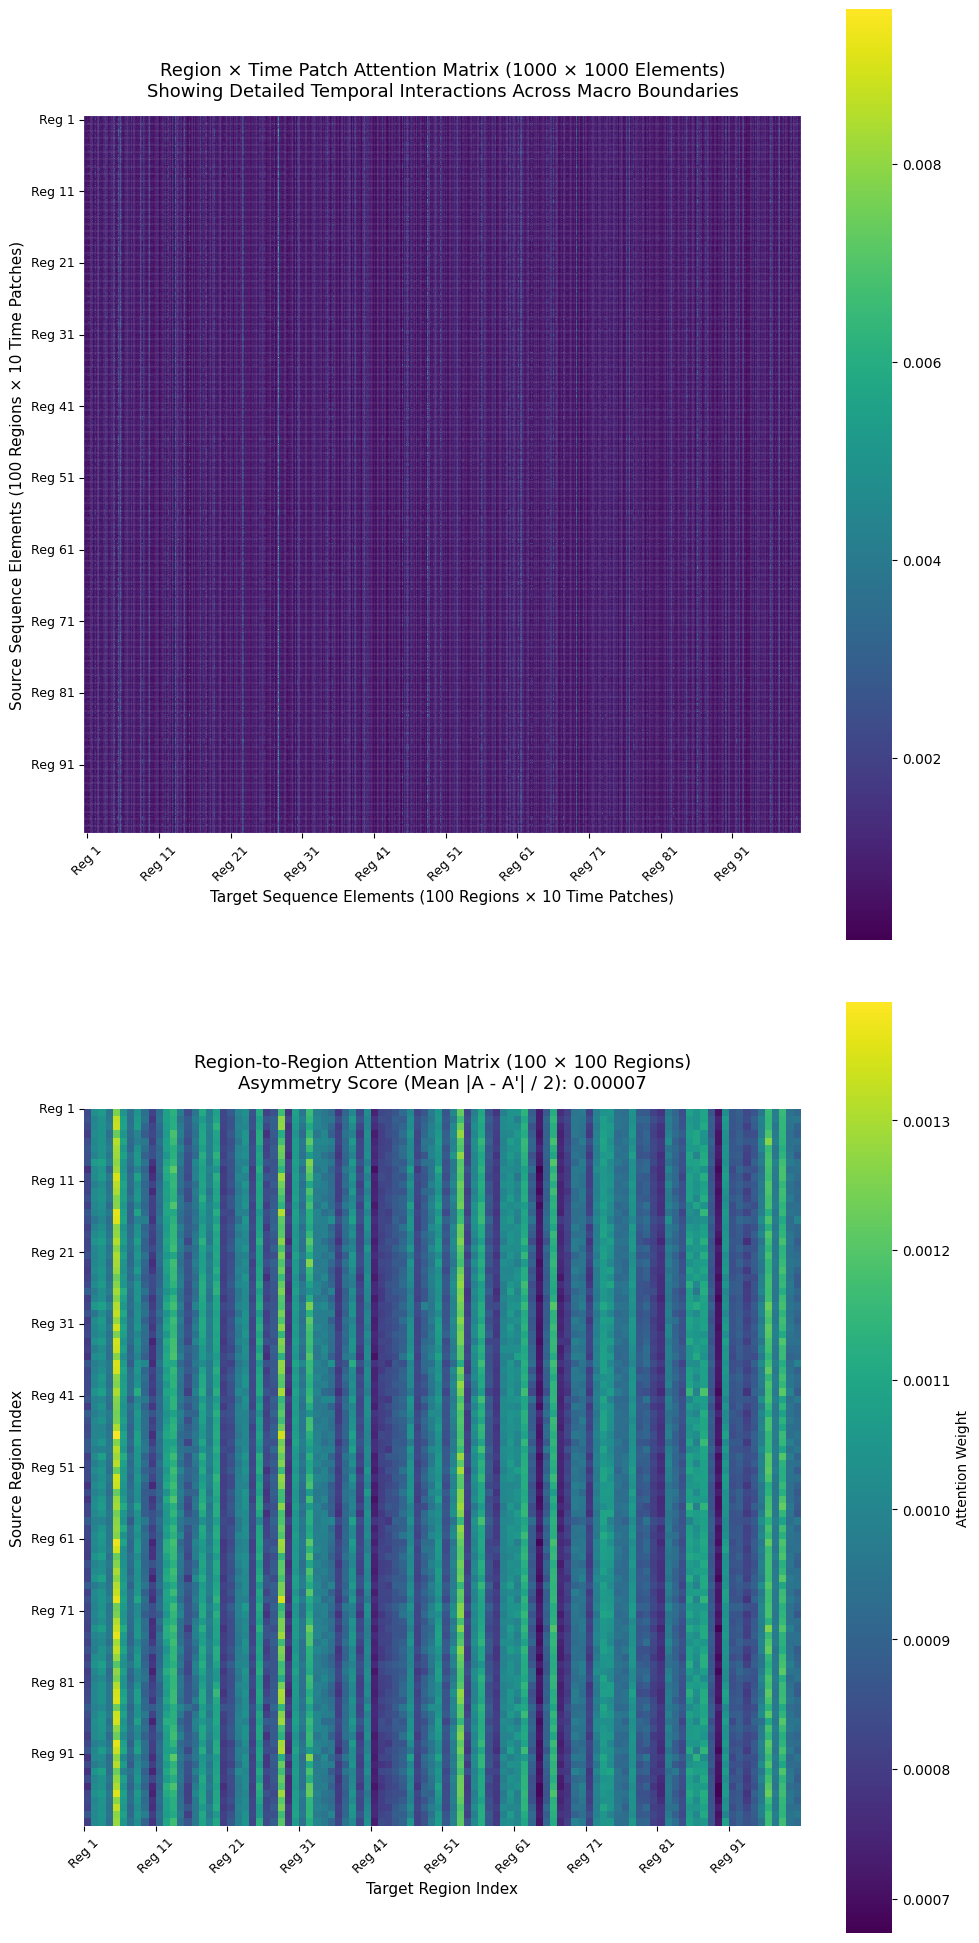

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# ==========================================
# 1. REGION SELECTION & CONFIGURATION
# ==========================================
# Change this to any slice or range (e.g., np.arange(0, 50) or np.arange(0, 424))
selected_indices = np.arange(0, 100) 
indices_tensor = torch.tensor(selected_indices, dtype=torch.long)

# Adaptive slicing based on your selection
tiny_fmri_data = tensor_data[:, indices_tensor, :].to(device)
tiny_coords = spatial_coords_base[:, indices_tensor, :].to(device)

num_regions = len(selected_indices)
num_patches = 10 #brainlm
num_timepoints = num_patches 
total_tokens = num_regions * num_timepoints

# Dynamic label step: targets roughly ~10 cleanly spaced labels across the axes
step = max(1, num_regions // 10) 
print(f"Processing {num_regions} regions ({total_tokens} tokens). Adaptive step: {step}")

# Prepare the Model
model.eval()
model.config.mask_ratio = 0.0 

# ==========================================
# 2. MODEL FORWARD PASS & REDUCTION
# ==========================================
with torch.no_grad():
    outputs = model.vit(
        signal_vectors=tiny_fmri_data,
        xyz_vectors=tiny_coords,
        output_attentions=True 
    )

# Shape: [num_windows, num_heads, sequence_length, sequence_length]
final_layer_attention = outputs.attentions[-1]

# Average out sliding windows (dim 0) and attention heads (dim 1)
avg_attention = final_layer_attention.mean(dim=(0, 1)) 

# Strip the [CLS] token at index 0 -> leaves the token-level matrix [500, 500]
attn_no_cls = avg_attention[1:, 1:] 

# Reshape and average out the temporal patch dimensions to get region-to-region [50, 50]
attn_reshaped = attn_no_cls.view(num_regions, num_timepoints, num_regions, num_timepoints)
subject_attention_matrix = attn_reshaped.mean(dim=(1, 3))

# ==========================================
# 3. METRIC CALCULATION (ASYMMETRY)
# ==========================================
token_matrix_np = attn_no_cls.detach().cpu().numpy()
region_matrix_np = subject_attention_matrix.detach().cpu().numpy()

# Calculate Asymmetry Score only for the regional breakdown matrix
anti_symmetric_part = (region_matrix_np - region_matrix_np.T) / 2
asymmetry_score = np.mean(np.abs(anti_symmetric_part))

# ==========================================
# 4. DUAL PLOT VISUALIZATION VERTICAL STACK
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))

# --- PLOT 1: REGION × TIME PATCH PROFILE ---
sns.heatmap(token_matrix_np, cmap='viridis', square=True, rasterized=True, ax=ax1)

# Overlay regional boundaries grid lines
for i in range(0, total_tokens + 1, num_timepoints):
    ax1.axhline(i, color='white', lw=0.3, alpha=0.3)
    ax1.axvline(i, color='white', lw=0.3, alpha=0.3)

ax1.set_title(
    f"Region × Time Patch Attention Matrix ({total_tokens} × {total_tokens} Elements)\n"
    f"Showing Detailed Temporal Interactions Across Macro Boundaries", 
    fontsize=13, pad=15
)
ax1.set_xlabel(f"Target Sequence Elements ({num_regions} Regions × {num_timepoints} Time Patches)", fontsize=11)
ax1.set_ylabel(f"Source Sequence Elements ({num_regions} Regions × {num_timepoints} Time Patches)", fontsize=11)

# Center ticks in the middle of each 10-token block
token_positions = np.arange((num_timepoints - 1) / 2, total_tokens, num_timepoints) 
token_labels = [f"Reg {i+1}" for i in range(num_regions)]
ax1.set_xticks(token_positions[::step])
ax1.set_yticks(token_positions[::step])
ax1.set_xticklabels(token_labels[::step], rotation=45, fontsize=9)
ax1.set_yticklabels(token_labels[::step], rotation=0, fontsize=9)


# --- PLOT 2: REGION-TO-REGION ATTENTION MATRIX ---
sns.heatmap(region_matrix_np, cmap='viridis', square=True, rasterized=True, ax=ax2, cbar_kws={'label': 'Attention Weight'})

ax2.set_title(
    f"Region-to-Region Attention Matrix ({num_regions} × {num_regions} Regions)\n"
    f"Asymmetry Score (Mean |A - A'| / 2): {asymmetry_score:.5f}", 
    fontsize=13, pad=15
)
ax2.set_xlabel("Target Region Index", fontsize=11)
ax2.set_ylabel("Source Region Index", fontsize=11)

# Apply step-pacing mapping cleanly directly to regional cell boundaries 
reg_positions = np.arange(num_regions)
reg_labels = [f"Reg {i+1}" for i in range(num_regions)]
ax2.set_xticks(reg_positions[::step])
ax2.set_yticks(reg_positions[::step])
ax2.set_xticklabels(reg_labels[::step], rotation=45, fontsize=9)
ax2.set_yticklabels(reg_labels[::step], rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
final_layer_attention.shape

torch.Size([3, 4, 1001, 1001])

In [41]:
full_attention = final_layer_attention[2].mean(dim=0)[1:, 1:]
full_attention.shape

torch.Size([1000, 1000])

In [42]:
# Attention for batch 1, avg heads, no CLS, last layer
full_attention = final_layer_attention[0].mean(dim=0)[1:, 1:]

# 2. Reshape into a 4D tensor: (Source Time, Source Region, Target Time, Target Region)
# Shape: (10, N, 10, N)
attn_4d = full_attention.view(num_timepoints, num_regions, num_timepoints, num_regions)

# 2. Reshape into a 4D tensor: (Source Region, Source Time, Target Region, Target Time)
attn_4d_alt = full_attention.view(num_regions, num_timepoints, num_regions, num_timepoints)

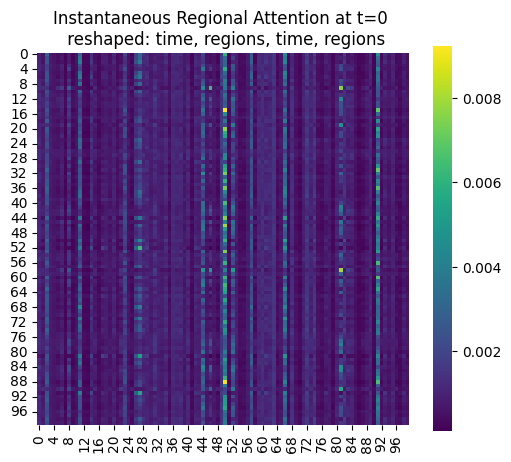

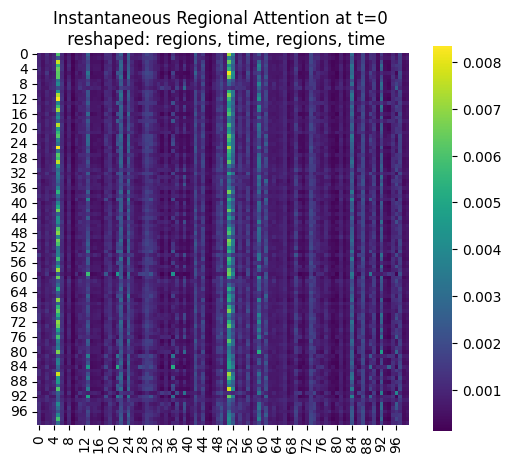

In [43]:
# Look at Source Time 0 attending to Target Time 0
# Shape: (424, 424)
t = 0
matrix_t = attn_4d[t, :, t, :] # time, regions, time, regions
matrix_t_alt = attn_4d_alt[:, t, :, t] # regions, time, regions, time


# Plot it
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix_t.cpu().numpy(), cmap='viridis', square=True, ax=ax)
ax.set_title(f"Instantaneous Regional Attention at t={t} \n reshaped: time, regions, time, regions")
plt.show() 

# Plot it
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix_t_alt.cpu().numpy(), cmap='viridis', square=True, ax=ax)
ax.set_title(f"Instantaneous Regional Attention at t={t} \n reshaped: regions, time, regions, time")
plt.show() 

Clearly, the shape is the expected one, now lets check what happens for several timesteps

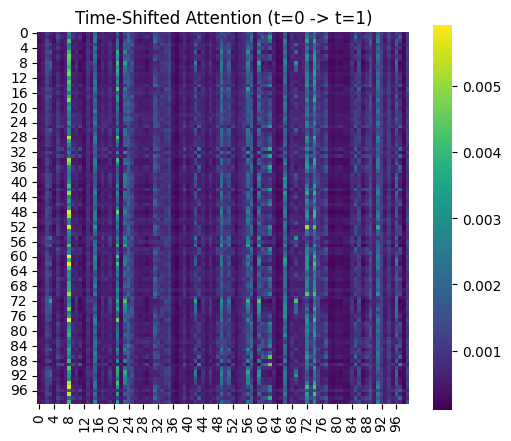

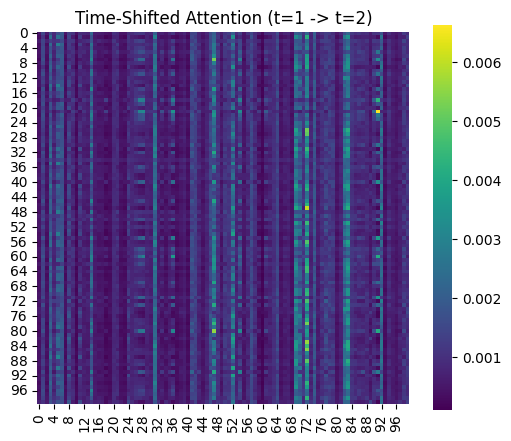

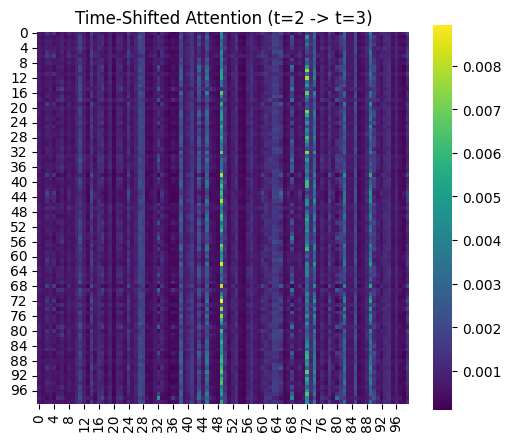

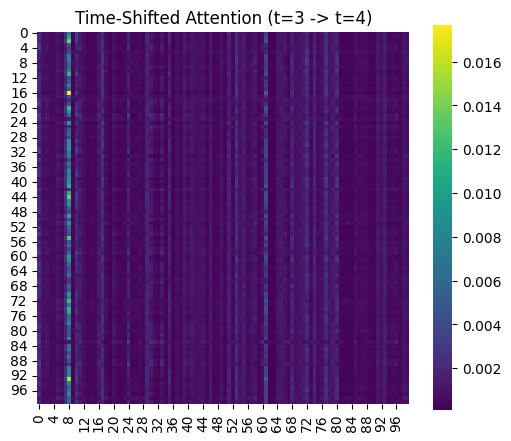

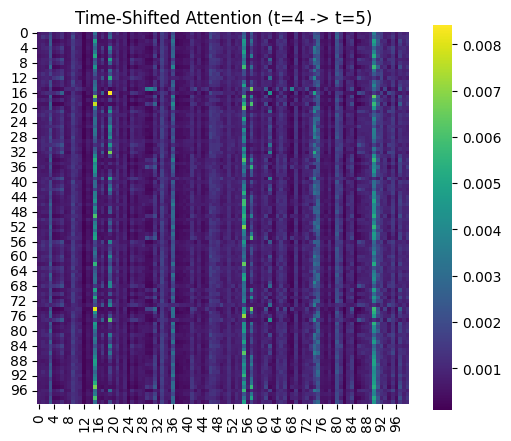

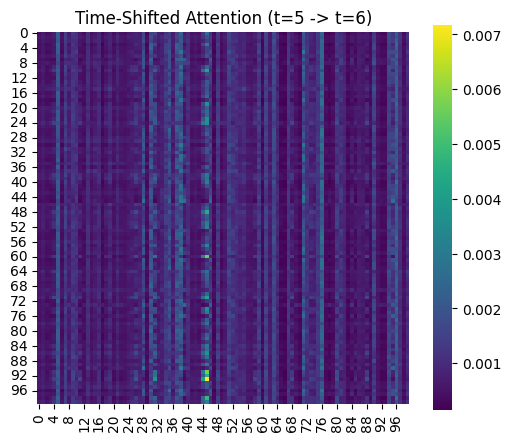

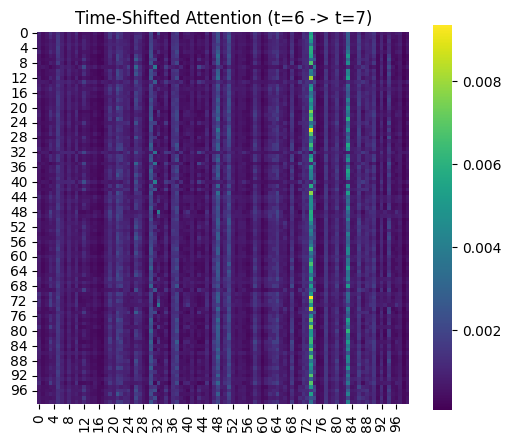

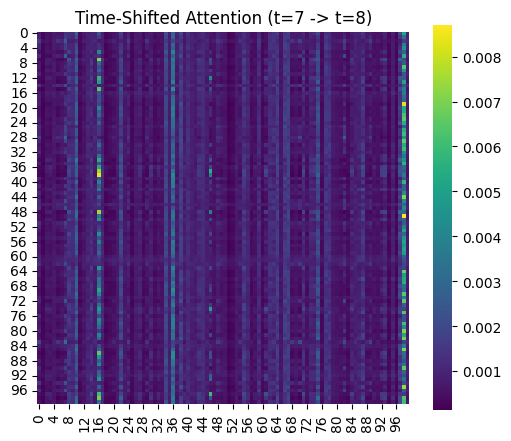

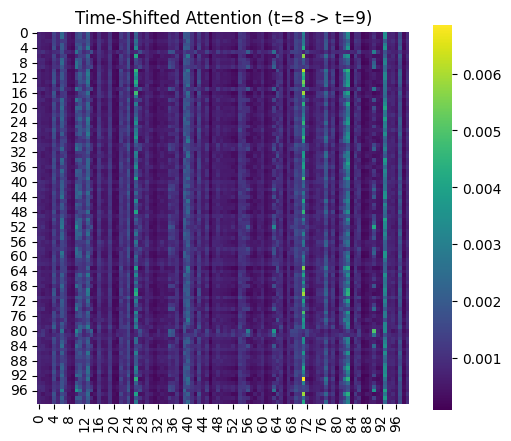

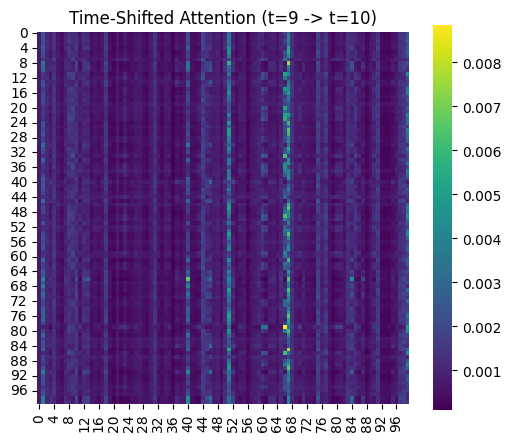

In [26]:
for t in range(num_timepoints):
    att = attn_4d[t, :, t, :]
    # Plot it
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(att.cpu().numpy(), cmap='viridis', square=True, ax=ax)
    ax.set_title(f"Time-Shifted Attention (t={t} -> t={t+1})")

in avg

Text(0.5, 1.0, 'Avg Time-Shifted Attention (t -> t+1)')

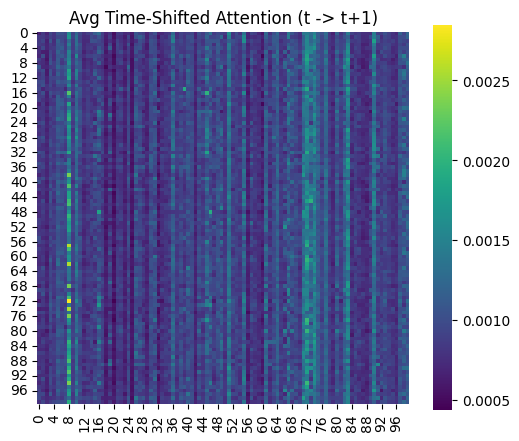

In [30]:
# Average time-shifted attention: source at t, target at t+1
avg_shifted_attention = torch.stack([
    attn_4d[t, :, t+1, :]
    for t in range(num_timepoints - 1)
]).mean(dim=0)  # [num_regions, num_regions]

# Plot it
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_shifted_attention.cpu().numpy(), cmap='viridis', square=True, ax=ax)
ax.set_title(f"Avg Time-Shifted Attention (t -> t+1)")

Text(0.5, 1.0, 'Time-Shifted Attention (t=0 -> t=1)')

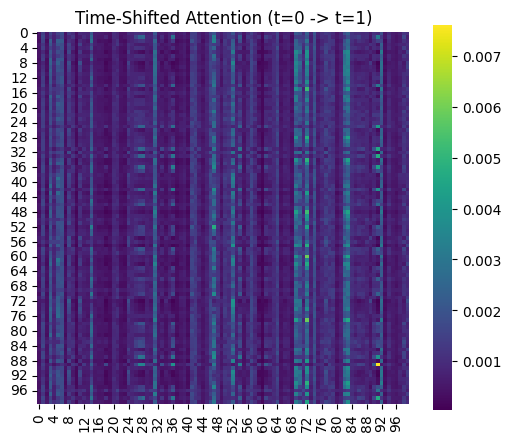

In [27]:
t = 0 # Choose your starting time step (0 through 8)

# Source is time t, Target is time t+1
# Shape: (424, 424)
matrix_shifted = attn_4d[t, :, t+1, :]

# Plot it
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix_shifted.cpu().numpy(), cmap='viridis', square=True, ax=ax)
ax.set_title(f"Time-Shifted Attention (t={t} -> t={t+1})")

For all subjects

In [35]:
import os
import sys
import h5py
import numpy as np
import torch

# ==========================================
# 1. DEFINE YOUR NOTEBOOK VARIABLES HERE
# ==========================================

# --- PATH CONFIGURATION FROM BASH ---
PROJ_DIR = "/home/mossf/projects/brainlm"
DATA_DIR = "/share/data1/mossf/data/brainlm"

INPUT_H5 = f"{DATA_DIR}/input/fmri_timeseries_subset_100.h5"
OUTPUT_DIR = f"{DATA_DIR}/outputs/attention_matrices"
COORDS_FILE = f"{DATA_DIR}/input/toolkit/atlases/A424_Coordinates.dat"
# HF_REPO = f"{DATA_DIR}/input/brainlm_hf_model"
# SUBFOLDER = "vitmae_111M"
CHECKPOINT_PATH = f"{DATA_DIR}/input/pretrained_models/2023-06-06-22_15_00-checkpoint-1400"

print("Initializing BrainLM Notebook Execution Sequence...")

# Hardware Dispatch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA Device Detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU found. Running on CPU.")

# ==========================================
# 2. LOAD INFRASTRUCTURE
# ==========================================
try:
    model = load_brainlm_model(CHECKPOINT_PATH).to(device)
    model.eval()
    model.config.mask_ratio = 0.0 # Disable masking for full-brain view
    
    spatial_coords_base = load_spatial_coordinates(COORDS_FILE)
except Exception as e:
    print(f"Failed to initialize core infrastructure: {str(e)}")
    # sys.exit(1) is too aggressive for a notebook, it will kill your kernel!
    raise RuntimeError("Halting execution. Fix the paths above.") 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# 3. EXECUTE SUBJECT LOOP
# ==========================================
with h5py.File(INPUT_H5, 'r') as f_in:
    ts_dataset = f_in['parcel_ts']
    subject_ids = f_in['subject_ids'][:]
    # n_subjects, _, _ = ts_dataset.shape
    n_subjects = 100
    
    print(f"Found {n_subjects} subjects. Saving outputs to: {OUTPUT_DIR}")

    for i in range(n_subjects):
        sub_id = subject_ids[i].decode('utf-8')
        out_file = os.path.join(OUTPUT_DIR, f"{sub_id}_attention.npy")
        
        # --- AUTO-RESUME CHECK ---
        if os.path.exists(out_file):
            print(f"Skipping [{i+1}/{n_subjects}] | Subject ID: {sub_id} (Already processed)")
            continue

        print(f"Processing [{i+1}/{n_subjects}] | Subject ID: {sub_id}")
        
        try:
            # 1. Prepare Subject Data
            raw_data = ts_dataset[i, 100:-100, :] # drop beggining and end

            # Robust Z-Scoring (Median/IQR) per region row
            # Compute along axis=1 (the time dimension)
            medians = np.median(raw_data, axis=1, keepdims=True)

            q75, q25 = np.percentile(raw_data, [75, 25], axis=1, keepdims=True)
            iqr = q75 - q25

            # Prevent division by zero just in case a region has completely flat data
            iqr = np.where(iqr == 0, 1.0, iqr)

            # 3. Apply the scaling
            normalized_data = (raw_data - medians) / iqr
            
            # Apply sliding window logic, resulting in [num_windows, 424, 490]
            fmri_windows = preprocess_subject_data(normalized_data, window_size=200, num_windows=5).to(device) 
            num_windows = fmri_windows.shape[0]
            
            # Expand coordinates to match the number of windows
            spatial_coords = spatial_coords_base.repeat(num_windows, 1, 1).to(device)
            
            # 2. Forward Pass
            with torch.no_grad():
                outputs = model.vit(
                    signal_vectors=fmri_windows,
                    xyz_vectors=spatial_coords,
                    output_attentions=True
                )
            
            # 3. Extract and Process the Final Layer Attention Matrix
            final_layer_attention = outputs.attentions[-1]

            # Average across attention heads (dim 1)
            avg_attention = final_layer_attention.mean(dim=(1))

            # Drop the [CLS] token at index 0
            attn_no_cls = avg_attention[:, 1:, 1:]

            # num_regions = 424
            # num_patches = attn_no_cls.shape[0] // num_regions  # Should be 10

            # # Reshape and reduce over time patches
            # attn_reshaped = attn_no_cls.view(num_regions, num_patches, num_regions, num_patches)
            # region_mean = attn_reshaped.mean(dim=(1, 3))
            # region_max  = attn_reshaped.amax(dim=(1, 3))

            # # Move to CPU and convert to numpy for saving
            # subject_mean_np = region_mean.cpu().numpy().astype('float32')
            # subject_max_np  = region_max.cpu().numpy().astype('float32')

            # 4. Save to Disk
            np.save(out_file, attn_no_cls)

        except Exception as sub_error:
            print(f"SKIPPED Subject {sub_id} due to processing error: {str(sub_error)}")
            continue
            
        finally:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

print("All operations complete.")

Initializing BrainLM Notebook Execution Sequence...
No GPU found. Running on CPU.
Found 100 subjects. Saving outputs to: /share/data1/mossf/data/brainlm/outputs/attention_matrices
Processing [1/100] | Subject ID: Sub_0000
Processing [2/100] | Subject ID: Sub_0001
Processing [3/100] | Subject ID: Sub_0002
Processing [4/100] | Subject ID: Sub_0004
Processing [5/100] | Subject ID: Sub_0005
Processing [6/100] | Subject ID: Sub_0006
Processing [7/100] | Subject ID: Sub_0007
Processing [8/100] | Subject ID: Sub_0008
Processing [9/100] | Subject ID: Sub_0009
Processing [10/100] | Subject ID: Sub_0010
Processing [11/100] | Subject ID: Sub_0011
Processing [12/100] | Subject ID: Sub_0012
Processing [13/100] | Subject ID: Sub_0013
Processing [14/100] | Subject ID: Sub_0014
Processing [15/100] | Subject ID: Sub_0015
Processing [16/100] | Subject ID: Sub_0016
Processing [17/100] | Subject ID: Sub_0017
Processing [18/100] | Subject ID: Sub_0018
Processing [19/100] | Subject ID: Sub_0019
Processing [